![Imagen](https://www.bcra.gob.ar/Imagenes/header/encabezado.jpg)


# Aprendiendo a detectar clientes en riesgo: Estrategias analíticas para el Churn Bancario
## Práctico n°1
### Análisis y visualización

"Aprendiendo a Detectar Clientes en Riesgo: Estrategias Analíticas para el Churn Bancario"

Práctico n°1
Análisis y visualización
En la siguiente notebook, realizaremos la carga del dataset inicial que utilizarán para el práctico de Análisis y Visualización. Posteriormente, se detallarán las consignas a seguir para la aprobación del trabajo práctico.

El objetivo de este proyecto es aprender la metodología utilizada para prevenir el abandono de clientes en la industria financiera. El dataset incluye información pertinente a clientes, datos demográficos, cantidad de productos activos, inactividad, nivel de utilización de tarjetas de crédito y otros datos relevantes.


Objetivos:
# Análisis estadístico de variables.
Seleccionar un conjunto de variables que consideren particularmente de interés para analizar, y a continuación:

1 - Usar distintos tipos de gráficos que permitan clarificar la distribucion de las variables. Comentar tipos de distribucion encontrados. ¿Es simetríca o asimétrica? ¿A qué se podría deber dicho comportamiento? Es importante que comenten sus observaciones

2 - Calcular estadísticos descriptivos (media, mediana, moda, desviación estándar)

3 - Grafique un gráfico de Boxplot para cada variable y comente los resultados

3 - ¿Existen valores atípicos? ¿Cuales? Expóngalos gráficamente

# Distribución de frecuencias

1 - Distribución etaria de los clientes por cortes de edad (elegir el mejor modo de mostrarlo)

2 - Distribución de Ingresos y relación con el nivel educacional

3 - Distribución del resto de las variables relevantes del dataset

4 - Cantidad de productos por cliente, ingreso promedio, limites de crédito, antigüedad en el banco, monto total de transacciones promedio últimos 12 meses.

5 - Hacer un análisis que relacione todos los datos construidos. El objetivo es presentar Insights de interés para el negocio. Ej: cantidad de productos activos por cortes con inactividad, promedio de saldo disponible en TC con limite de TC, etc.



# Análisis de probabilidades condicionales e independencia entre dos variables

1 - ¿Existe algún tipo de relación entre la inactividad del cliente y el nivel de endeudamiento?

2 - ¿Existe algún tipo de relación entre la inactividad del cliente, el ingreso, el tipo de producto y limite de crédito ?

3 - Resumir en un cuadro las características de un cliente que presenta una alta tasa de inactividad y casuísticas más comunes. Pueden expresarlo con una pequeña infografía comparándolos con los clientes de mayor actividad.

Utilizar gráficos para complementar el análisis

Pueden agregar más análisis que consideren relevantes que sumarán al contenido del práctico. Estos puntos son el mínimo requerido.

Entregas:
Breve informe en el cual desarrollen los puntos anteriores, el cual debe incluir :gráficos, resultados obtenidos y las conclusiones obtenidas (no agregar código al informe)

Notebook que refleje el trabajo realizado en Python.

### Importacion y lectura de datos

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
url = 'https://raw.githubusercontent.com/chrismartinezML/DiplodatosFAMAF_2025/refs/heads/main/Churn_CreditCardPrediction.csv'
df = pd.read_csv(url)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [ ]:
df.head(5)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


# Variables seleccionadas
Para esta etapa del análisis hemos decidido incorporar la totalidad de las variables disponibles en el DataFrame, de modo de aprovechar al máximo la información y no omitir ningún atributo del conjunto de datos.

In [ ]:
continuous_columns = [
    "Customer_Age",
    "Months_on_book",
    "Credit_Limit",
    "Total_Revolving_Bal",
    "Avg_Open_To_Buy",
    "Total_Amt_Chng_Q4_Q1",
    "Total_Trans_Amt",
    "Total_Trans_Ct",
    "Total_Ct_Chng_Q4_Q1",
    "Avg_Utilization_Ratio",

]

discrete_columns = [
    "Dependent_count",
    "Contacts_Count_12_mon",
    "Months_Inactive_12_mon",
    "Total_Relationship_Count",
]

numerical_columns = continuous_columns + discrete_columns

categorical_columns = [
    "Gender",
    "Education_Level",
    "Marital_Status",
    "Income_Category",
    "Card_Category",
    "Attrition_Flag"
]

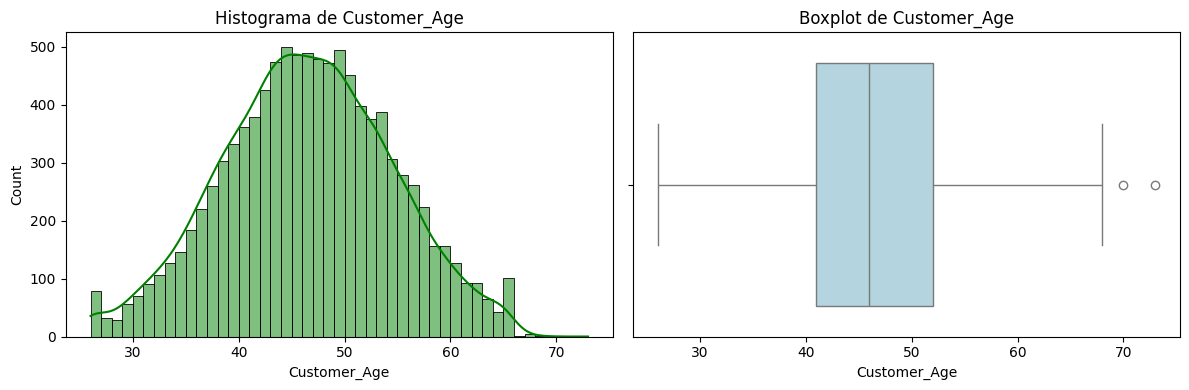

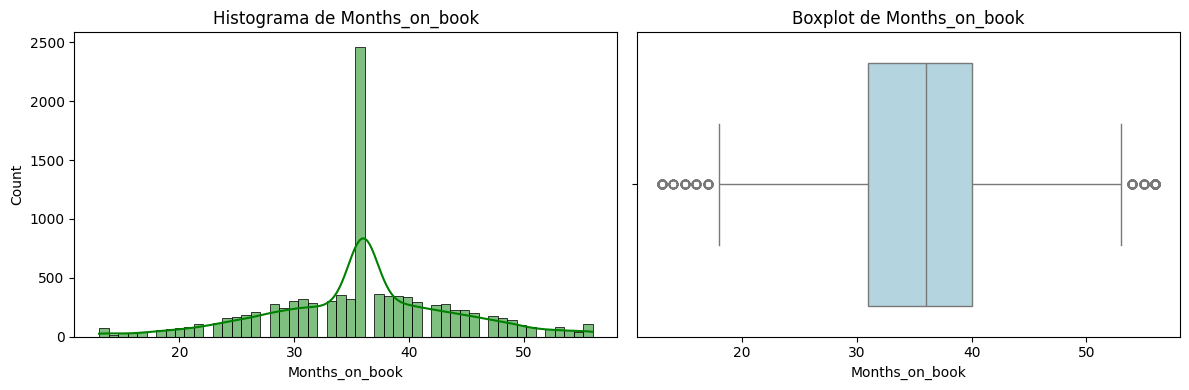

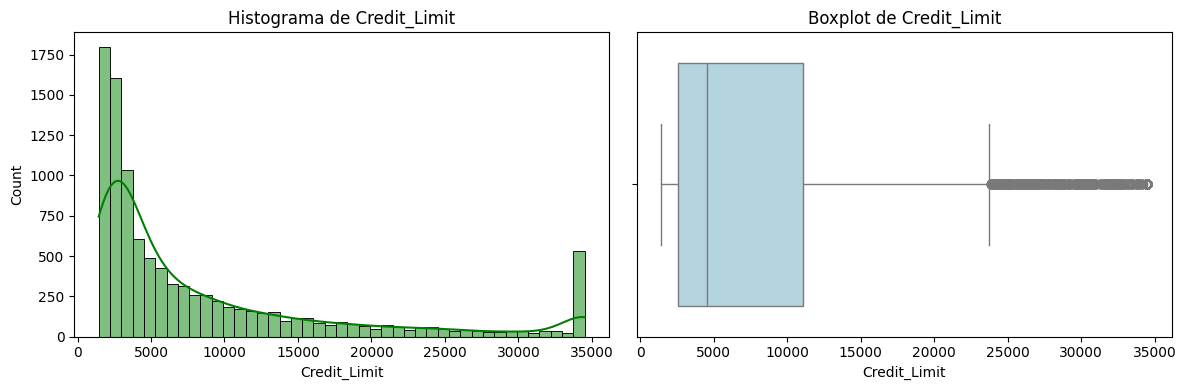

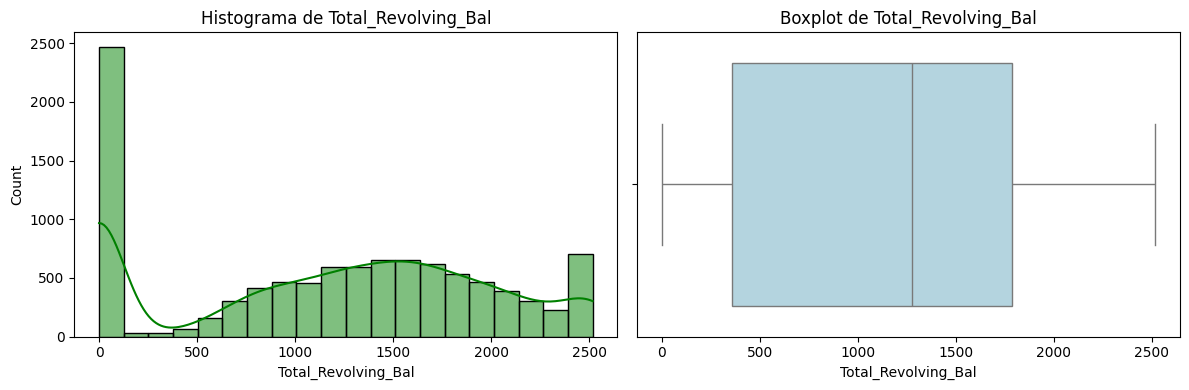

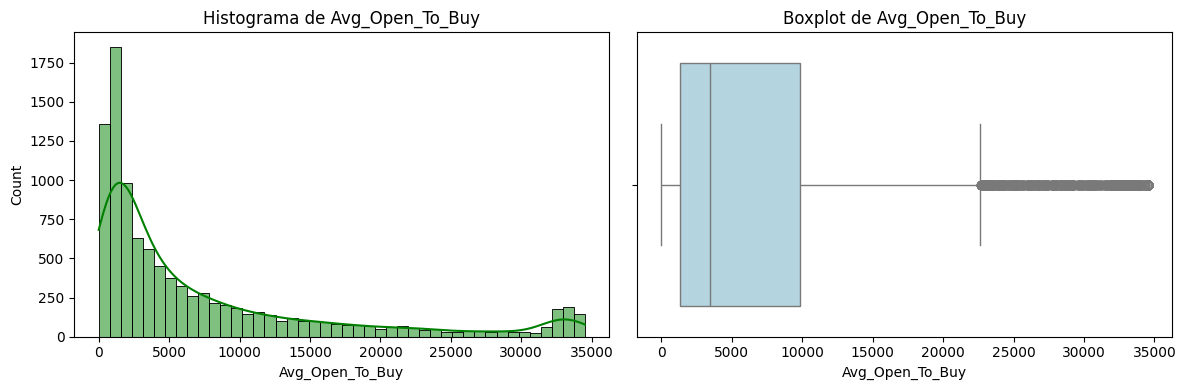

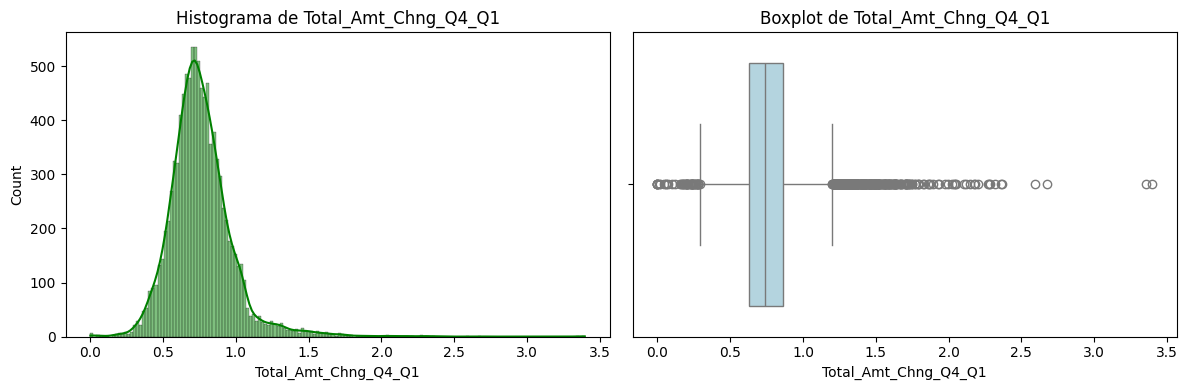

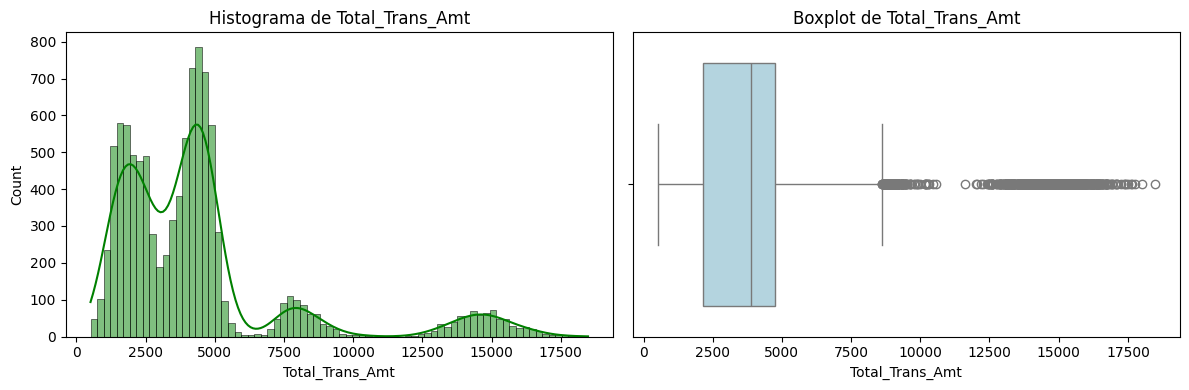

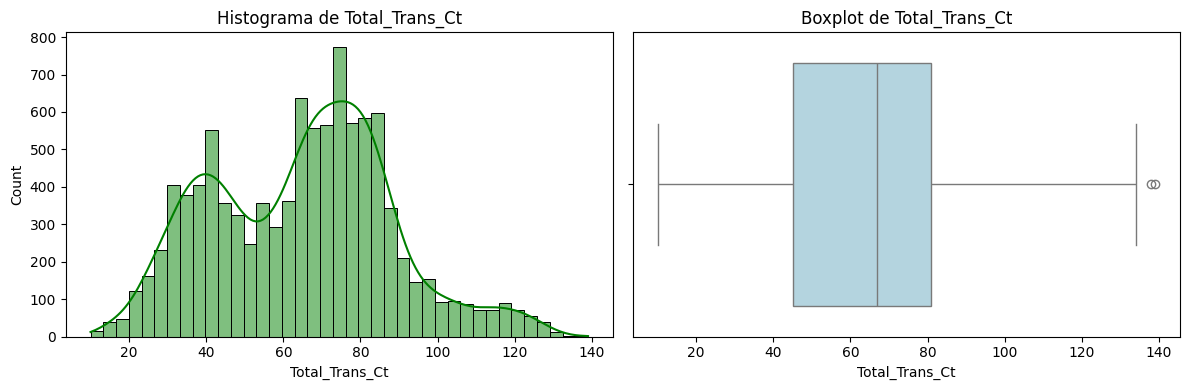

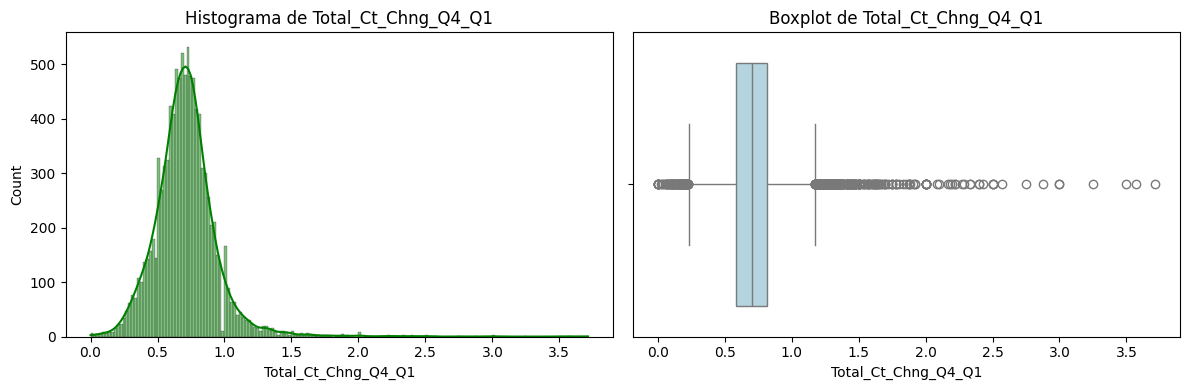

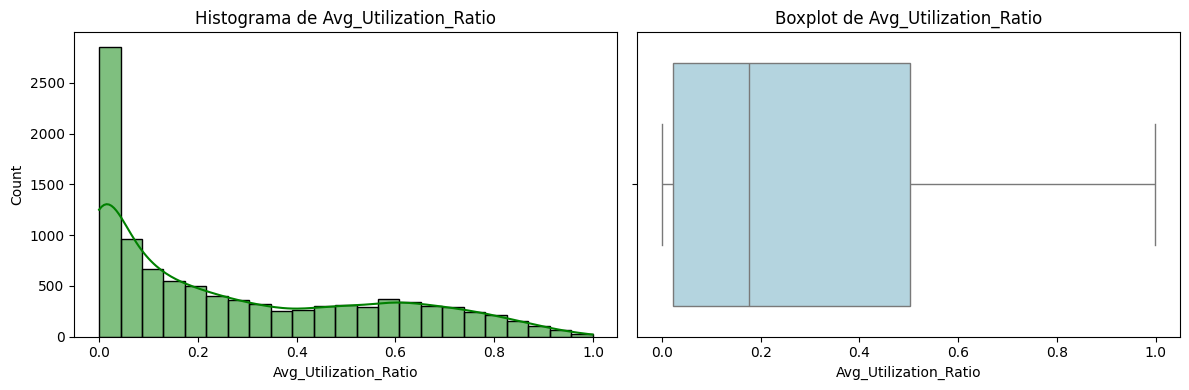

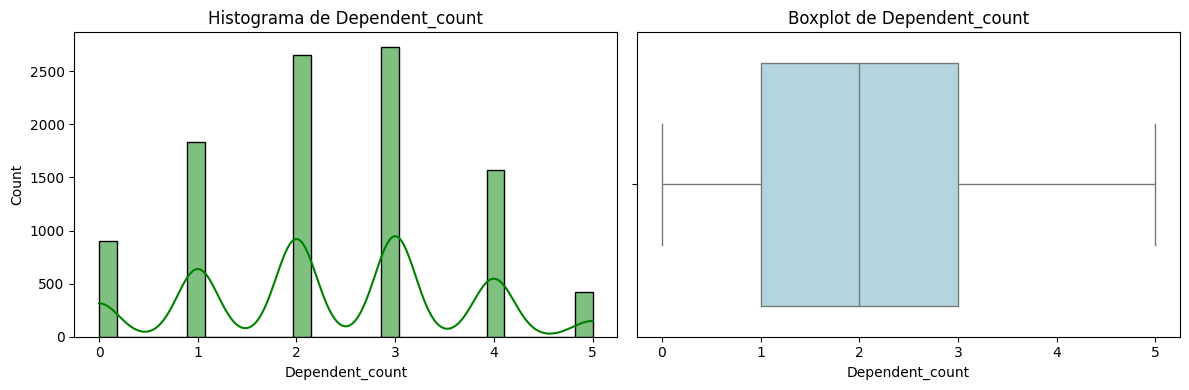

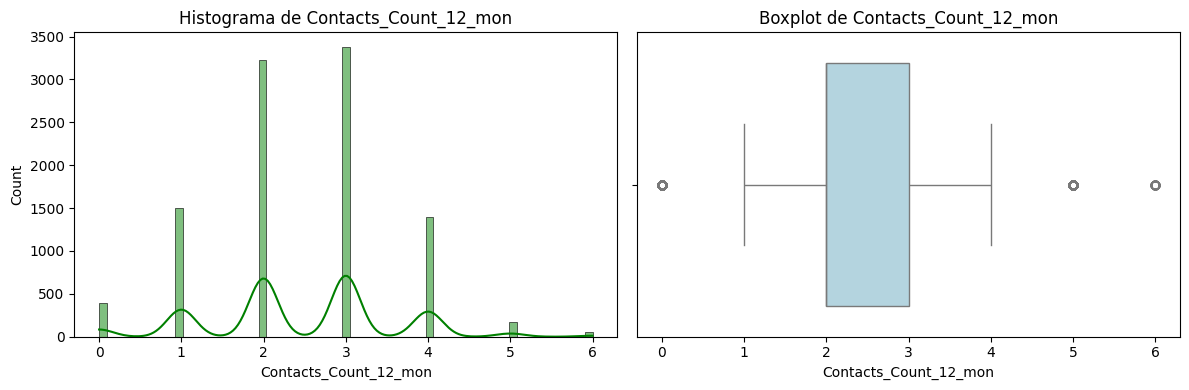

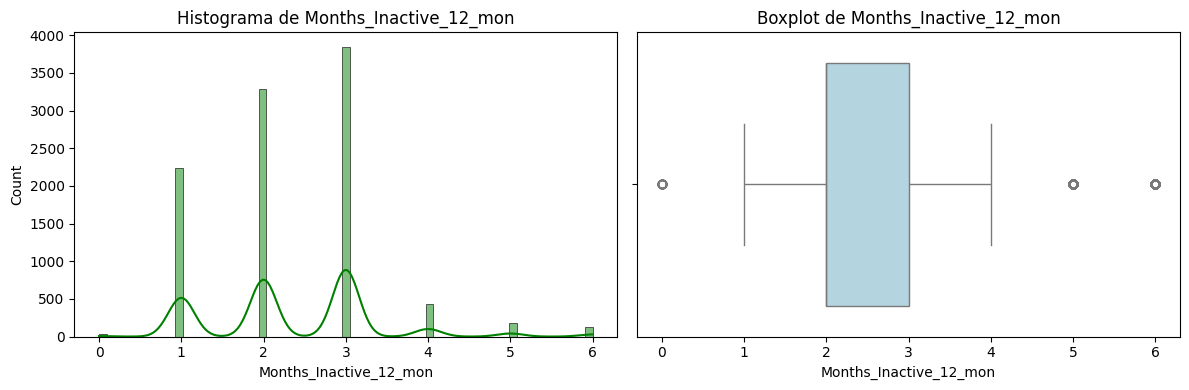

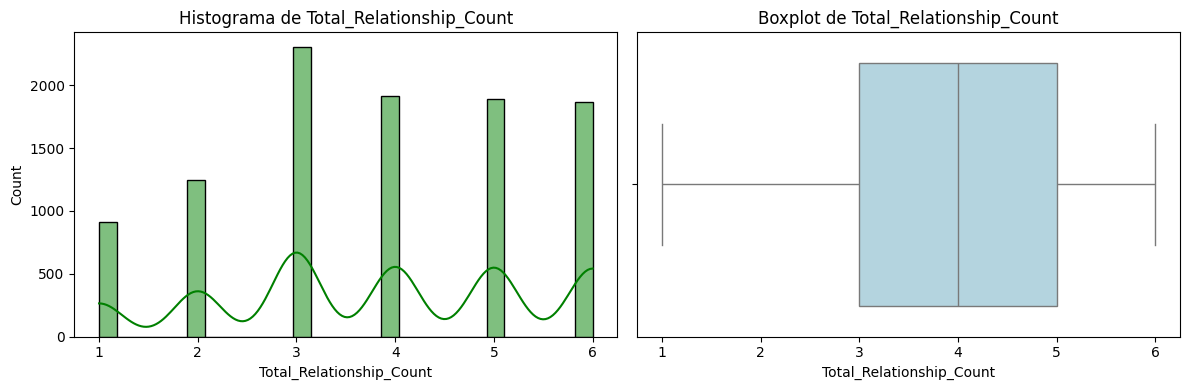

In [ ]:
for numerica in numerical_columns:
  fig, axs = plt.subplots(1, 2, figsize=(12, 4))

  #histograma
  sns.histplot(data=df, x=numerica, ax=axs[0], color='green', kde=True)
  axs[0].set_title(f'Histograma de {numerica}')


  #boxplot
  sns.boxplot(data=df, x=numerica, ax=axs[1], color='lightblue')
  axs[1].set_title(f'Boxplot de {numerica}')

  plt.tight_layout()
  plt.show()

### **Análisis de la distribución de variables numéricas**

Se generaron histogramas para todas las variables numéricas con el fin de entender su distribución. Se identificaron tres patrones principales:

- **Distribuciones Simétricas**: Variables demográficas como Customer_Age y Months_on_book muestran una distribución cercana a la normal, centrada en la mediana edad y una antigüedad de 3 años, respectivamente.

- **Distribuciones Asimétricas** (Sesgo a la Derecha): Las variables de naturaleza financiera, como Credit_Limit y Avg_Utilization_Ratio, están fuertemente sesgadas. La mayoría de los clientes se concentra en valores bajos (límites de crédito modestos y bajo uso de la tarjeta), con una larga cola de clientes de alto valor. Notablemente, la variable Total_Revolving_Bal presenta un pico muy alto en cero, indicando que una gran proporción de clientes no mantiene deudas de un mes para otro.

- **Distribuciones Multimodales**: Variables como Total_Trans_Amt y Total_Trans_Ct son bimodales, sugiriendo la existencia de al menos dos segmentos de clientes distintos: un grupo de "uso moderado" y otro de "uso intensivo". Otras variables discretas como Dependent_Count y Total_Relationship_Count muestran picos en valores enteros específicos.

### **Análisis de Valores Atípicos mediante Boxplots**
Para identificar la presencia de valores atípicos, se generaron diagramas de caja (boxplots) para todas las variables numéricas. Los resultados exponen gráficamente estos valores como puntos individuales fuera del rango intercuartílico.

Hallazgos Clave:

- **Presencia Masiva en Variables Financieras**: Se identificó una gran cantidad de valores atípicos en el extremo superior de las variables Credit_Limit, Avg_Open_To_Buy, y Total_Trans_Amt. Estos outliers no representan errores en los datos, sino un segmento de clientes de alto valor (VIP) cuyo comportamiento financiero (límites, gastos) es significativamente superior al del cliente promedio.

- **Atípicos como Señales de Alerta**: En las variables que miden el cambio en el comportamiento (Total_Amt_Chng_Q4_Q1 y Total_Ct_Chng_Q4_Q1), se observaron valores atípicos en ambos extremos. Los outliers en el extremo inferior (cercanos a cero) son particularmente relevantes para el negocio, ya que identifican a los clientes que han reducido drásticamente su actividad, una señal de alerta temprana de un posible abandono.

- **Ausencia de Atípicos Relevantes**: Variables como Total_Revolving_Bal no presentan valores atípicos significativos, indicando que el comportamiento de endeudamiento es más homogéneo en toda la cartera de clientes.

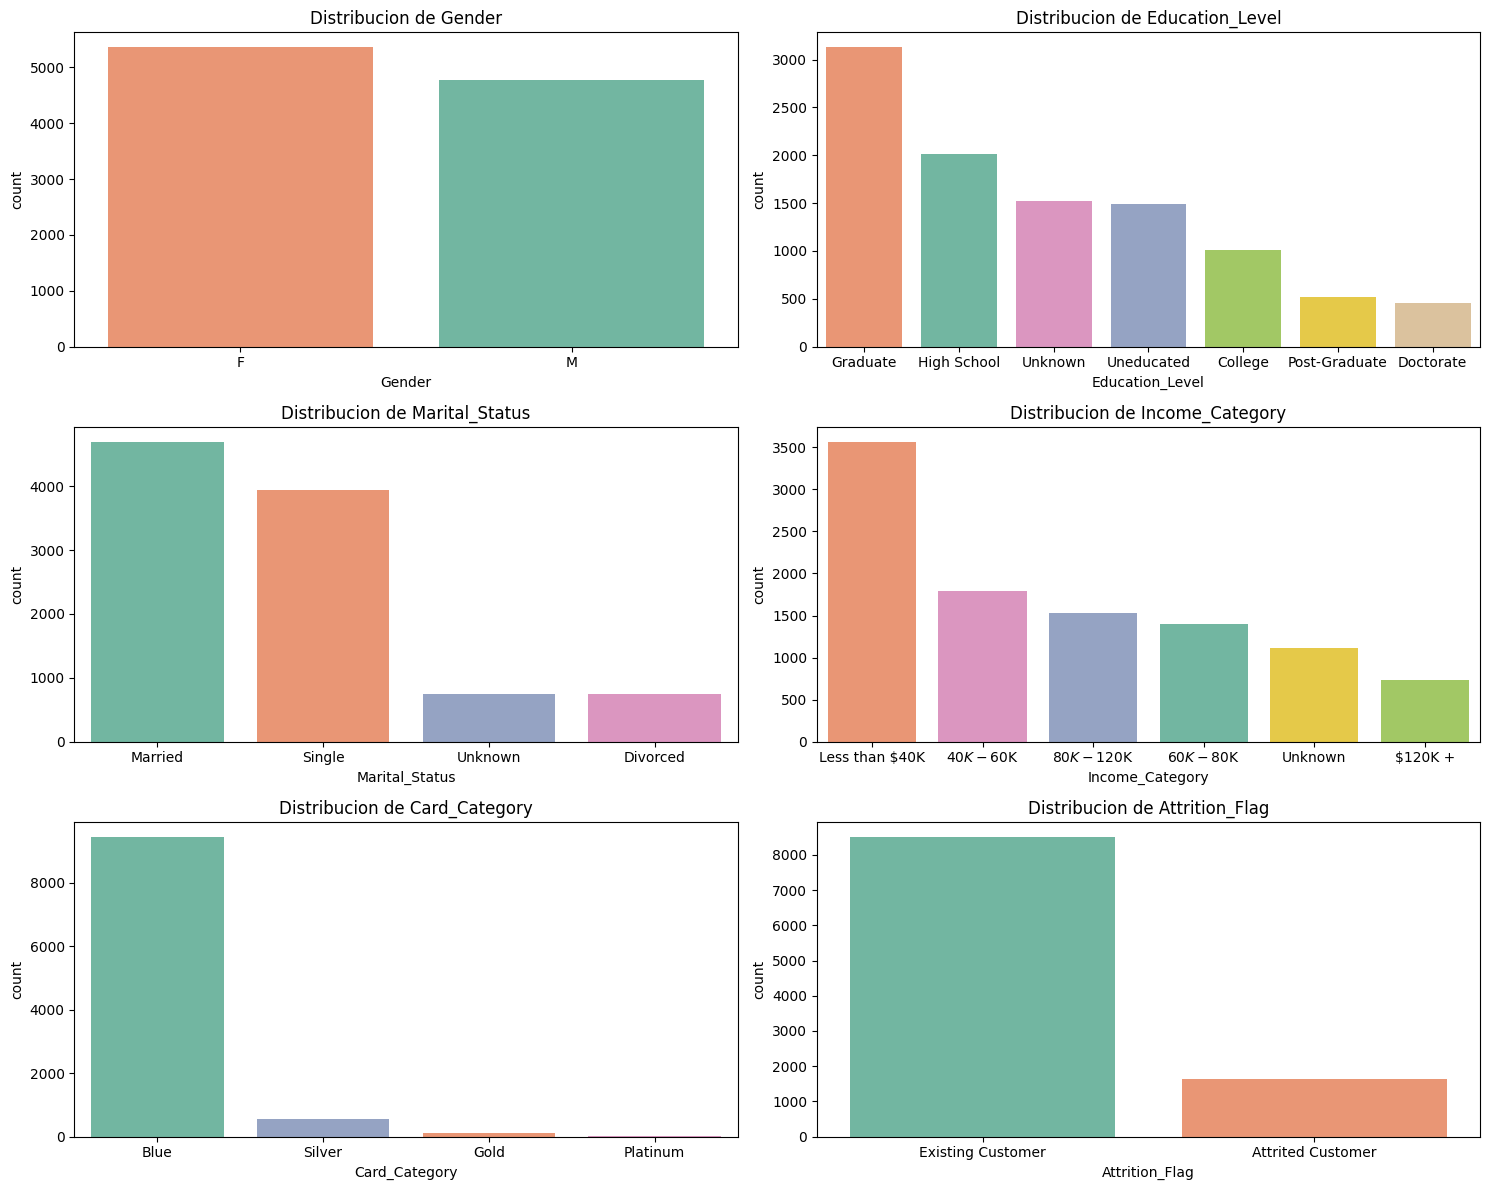

In [ ]:
plt.figure(figsize=(15, 12))

for i, categorica in enumerate(categorical_columns):
  plt.subplot(3, 2, i + 1)
  categorias_unicas = df[categorica].nunique()
  sns.countplot(data=df, x=categorica, order=df[categorica].value_counts().index, palette=sns.color_palette("Set2", n_colors=categorias_unicas), hue=categorica, legend=False)
  plt.title(f'Distribucion de {categorica}')

plt.tight_layout()
plt.show()

### **Análisis de la Distribución de Variables Categóricas**
Para complementar el análisis, se generaron gráficos de barras para las variables categóricas, revelando el perfil cualitativo de la cartera de clientes.

**Hallazgos Principales**:

- Tasa de Abandono (Attrition_Flag): El dataset presenta un desbalanceo de clases significativo, con una tasa de abandono (churn) de aproximadamente el 16%.

- Perfil Demográfico: La base de clientes es diversa, con una ligera mayoría femenina y una concentración en los estados civiles de "Casado" y "Soltero". A nivel educativo, los clientes "Graduados" y de "Secundaria" son los más comunes.

- Perfil de Producto (Card_Category): Se observa una dependencia casi total del producto de entrada, la tarjeta "Blue", que constituye más del 90% de las tarjetas emitidas. Las tarjetas premium (Silver, Gold, Platinum) son productos de nicho con una penetración muy baja.

- Calidad de Datos: En variables como Education_Level y Marital_Status existe una categoría "Unknown", indicando oportunidades para mejorar la recolección de datos demográficos.

In [ ]:
from scipy import stats

for numerica in numerical_columns:
  print(f'-----{numerica}-----')
  print(f'Media: {df[numerica].mean():.2F}')
  print(f'Mediana: {df[numerica].median():.2F}')
  moda = stats.mode(df[numerica], keepdims=True).mode[0]
  print(f'Moda: {moda}')
  print(f'Desviacion Estandar: {df[numerica].std():.2F}')
  print('\n')

for categorica in categorical_columns:
  print(f'-----{categorica}-----')
  moda = df[categorica].mode()[0]
  print(f'Moda: {moda}')
  print('\n')



-----Customer_Age-----
Media: 46.33
Mediana: 46.00
Moda: 44
Desviacion Estandar: 8.02


-----Months_on_book-----
Media: 35.93
Mediana: 36.00
Moda: 36
Desviacion Estandar: 7.99


-----Credit_Limit-----
Media: 8631.95
Mediana: 4549.00
Moda: 34516.0
Desviacion Estandar: 9088.78


-----Total_Revolving_Bal-----
Media: 1162.81
Mediana: 1276.00
Moda: 0
Desviacion Estandar: 814.99


-----Avg_Open_To_Buy-----
Media: 7469.14
Mediana: 3474.00
Moda: 1438.3
Desviacion Estandar: 9090.69


-----Total_Amt_Chng_Q4_Q1-----
Media: 0.76
Mediana: 0.74
Moda: 0.791
Desviacion Estandar: 0.22


-----Total_Trans_Amt-----
Media: 4404.09
Mediana: 3899.00
Moda: 4253
Desviacion Estandar: 3397.13


-----Total_Trans_Ct-----
Media: 64.86
Mediana: 67.00
Moda: 81
Desviacion Estandar: 23.47


-----Total_Ct_Chng_Q4_Q1-----
Media: 0.71
Mediana: 0.70
Moda: 0.667
Desviacion Estandar: 0.24


-----Avg_Utilization_Ratio-----
Media: 0.27
Mediana: 0.18
Moda: 0.0
Desviacion Estandar: 0.28


-----Dependent_count-----
Media: 2.35
Me

# **Customer_Age (EDAD)**
Gráficos:

El histograma muestra una distribución relativamente simétrica y cercana a normal, con un pico alrededor de los 44-46 años.

El boxplot revela algunos valores atípicos, pero no son muchos ni extremos.

Estadísticos:

Media: 46.33 años

Mediana: 46 años (muy cercana a la media)

Moda: 44 años

Desviación estándar: 8.02 años

La edad media del cliente está en torno a los 46 años, con una distribución bastante equilibrada, lo que sugiere que el banco tiene clientes de una edad adulta consolidada. La cercanía entre media y mediana indica poca asimetría, por lo que no hay sesgos importantes en la distribución de edades. Esto es relevante porque los clientes jóvenes suelen mostrar más rotación de productos y podrían tener patrones diferentes de abandono, mientras que los clientes más adultos pueden ser más estables

# **Credit_Limit (Límite de la Tarjeta)**

Gráficos:
El histograma muestra una distribución asimétrica hacia la derecha (sesgo positivo), con un pico claro en torno a los $4.549, que coincide con la mediana.

Estadísticos:

Moda: $34.516

Mediana: $4.549

Media: $8.631,95

Desviación estándar: $9.088,78

La variable presenta una distribución fuertemente sesgada hacia la derecha, con una mayoría de clientes que tienen límites de crédito bajos (alrededor de $4.500), pero algunos pocos con valores muy altos que empujan la media hacia arriba. Esto explica que la media sea considerablemente mayor que la mediana, y a su vez que la moda (el valor más frecuente) esté aún más lejos, representando los valores más altos atípicos.

El boxplot confirma la presencia de una alta cantidad de valores atípicos por encima de los $30.000. Estos outliers pueden estar relacionados con clientes de alto poder adquisitivo o con un historial crediticio más largo o confiable, y merecen una revisión más detallada.

# **Total_Trans_Ct (Cantidad Total de Transacciones - Últimos 12 meses)**
Gráfico:
La variable presenta una distribución bimodal, lo que indica que hay dos grupos de clientes con comportamientos diferentes en cuanto a la cantidad de transacciones. La primera "curva" se encuentra cerca de las 45 transacciones, y la segunda, más pronunciada, alrededor de las 75 transacciones, que es donde se concentra la mayor densidad de clientes activos.

El boxplot muestra muy pocos outliers, lo que indica que la mayoría de los clientes se agrupa dentro de un rango definido.

Estadísticos:

Media: 64.86 transacciones

Mediana: 67 transacciones

Moda: 81 transacciones

Desviación estándar: 23.47

La cercanía entre la media (64.86) y la mediana (67) sugiere que la distribución, a pesar de ser bimodal, no está sesgada significativamente. La moda (81) indica que ese valor es el más frecuente dentro del conjunto de datos, posiblemente asociado a clientes con mayor actividad.

La forma bimodal puede reflejar dos perfiles de clientes: uno más inactivo o moderado (menos transacciones) y otro más activo (mayor uso del servicio). Este tipo de patrón es muy relevante para el análisis del churn, ya que los clientes con menor número de transacciones podrían estar en mayor riesgo de abandono.


# **Avg_Utilization_Ratio (Promedio de ratio de utilización de TC en los últimos 12 meses)**
Gráfico:
La variable presenta una distribución fuertemente sesgada hacia la derecha. La mayoría de los clientes se concentra en valores muy bajos de utilización, y no se observan outliers significativos.

Estadísticos:

Moda: 0.00

Mediana: 0.18

Media: 0.27

Desviación estándar: 0.28

La moda de 0 confirma que un gran número de clientes no utilizó su tarjeta de crédito en absoluto durante el año. La mediana (0.18) y la media (0.27) indican que, en promedio, los clientes utilizaron entre el 18% y el 27% de su límite de crédito mensualmente, lo cual es relativamente bajo.

Este bajo nivel de uso puede interpretarse como una falta de compromiso con el producto, lo que constituye una señal temprana de desinterés o desconexión, y por ende, un potencial predictor del abandono (churn).

# **Contacts_Count_12_mon (Cantidad de contactos con el banco en los últimos 12 meses)**
Gráfico:
La variable presenta una distribución aproximadamente simétrica, cercana a una distribución normal. El valor más frecuente es 3 contactos, y no se observa una cantidad significativa de outliers.

Estadísticos:

Moda: 3

Mediana: 2

Media: 2.46

Desviación estándar: 1.11

La cercanía entre media, mediana y moda indica una distribución equilibrada, sin sesgos marcados. La mayoría de los clientes se ha contactado con el banco entre 2 y 3 veces en el último año.

Este comportamiento puede ser relevante para predecir el abandono: una mayor cantidad de contactos podría estar asociada a problemas no resueltos, insatisfacción o fricción con el servicio. Por otro lado, un número muy bajo de contactos también podría reflejar desinterés o desconexión.

# **Months_Inactive_12_mon (Cantidad de meses de inactividad en los últimos 12 meses)**
Gráfico:
La distribución de esta variable es ligeramente sesgada hacia la derecha, con un mayor número de clientes que han estado inactivos entre 1 y 3 meses.
El boxplot muestra muy pocos outliers, lo que sugiere que los valores extremos son poco frecuentes.

Estadísticos:

Moda: 3

Mediana: 2

Media: 2.34

Desviación estándar: 1.01

Interpretación:
La moda (3), la mediana (2) y la media (2.34) están bastante cerca entre sí, lo cual sugiere una distribución relativamente equilibrada, aunque con una leve asimetría hacia la derecha. Esto se debe a un pequeño grupo de clientes con períodos de inactividad prolongados (5 o más meses).

El hecho de que la mayoría de los clientes haya estado inactivo durante 2 o 3 meses en el año es una señal de desapego parcial. Aunque no implica abandono inmediato, sí podría anticipar riesgo de churn si la tendencia continúa.

Clientes con mayor inactividad probablemente muestran tasas de abandono más elevadas.

In [ ]:
#ver maximo en customer_age
df['Customer_Age'].max()

73

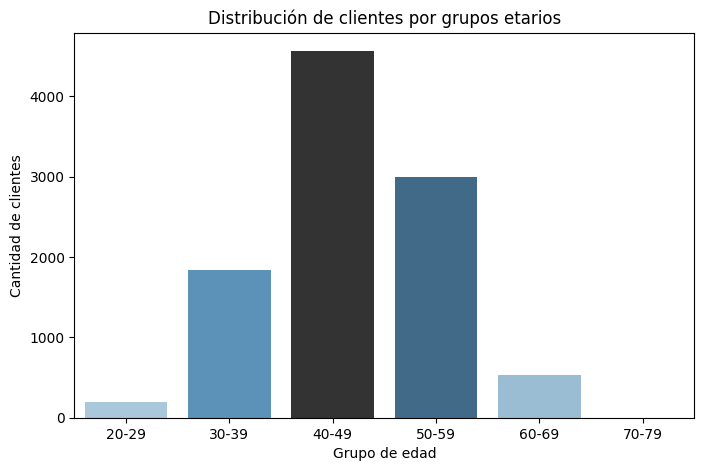

In [ ]:
# Crear cortes de edad
bins = [20, 30, 40, 50, 60, 70, 80]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79']
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels, right=False)

# Contar cantidad por grupo
age_dist = df['Age_Group'].value_counts().sort_index()

# Graficar
plt.figure(figsize=(8,5))
sns.barplot(x=age_dist.index, y=age_dist.values, hue=age_dist, legend=False, palette='Blues_d')
plt.title('Distribución de clientes por grupos etarios')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de clientes')
plt.show()


In [ ]:
from pandas.api.types import CategoricalDtype

# Orden lógico de ingresos
orden_ingresos = [
    'Less than $40K',
    '$40K - $60K',
    '$60K - $80K',
    '$80K - $120K',
    '$120K +',
    'Unknown']

# Convertir Income_Category a tipo categórico ordenado
tipo_ingresos = CategoricalDtype(categories=orden_ingresos, ordered=True)
df['Income_Category'] = df['Income_Category'].astype(tipo_ingresos)

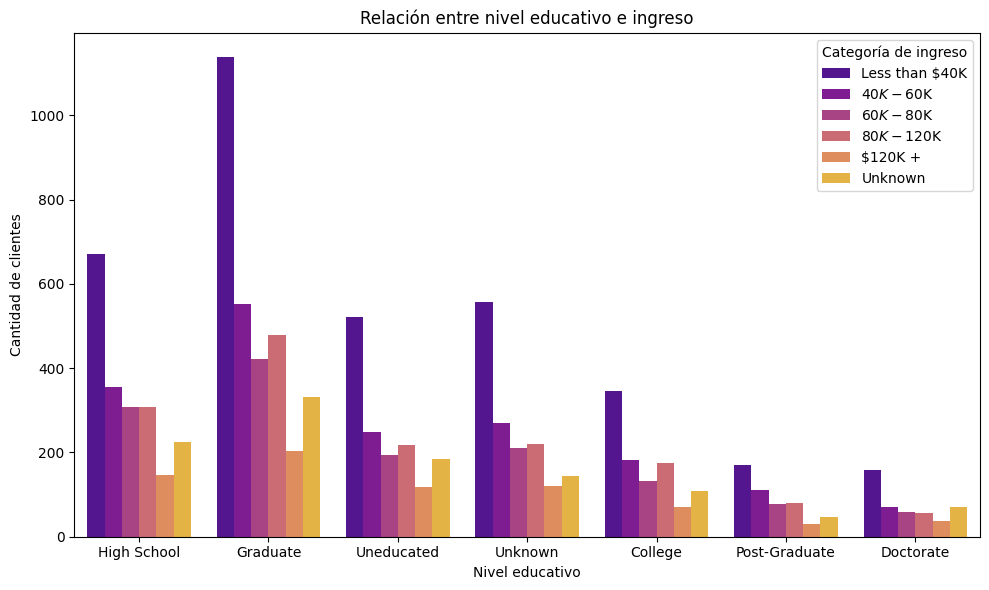

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Education_Level', hue='Income_Category', palette='plasma')
plt.title('Relación entre nivel educativo e ingreso')
plt.xlabel('Nivel educativo')
plt.ylabel('Cantidad de clientes')
plt.legend(title='Categoría de ingreso')
plt.tight_layout()
plt.show()

In [ ]:
def graficate_distribution(column_name, hue):
    plt.figure(figsize=(6,4))

    # Distribución por Attrition_Flag
    plt.subplot(1, 1, 1)
    sns.histplot(df, x=column_name, hue=hue, bins=30, element='step', stat='density', common_norm=False, alpha=0.5)
    plt.title(f'Distribución de {column_name} ' + hue)

    plt.tight_layout()
    plt.show()

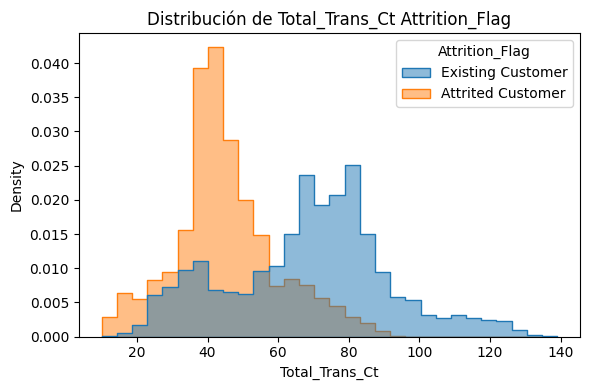

In [ ]:
graficate_distribution("Total_Trans_Ct", 'Attrition_Flag')

Los clientes que generan un mayor número de transacciones anuales tienen mucha más probabilidad de permanecer, mientras que quienes realizan menos movimientos tienden significativamente más a darse de baja. Esto sugiere que el volumen de uso es un predictor muy relevante de churn: cuantos más intercambios hace un cliente, menor su riesgo de abandono.

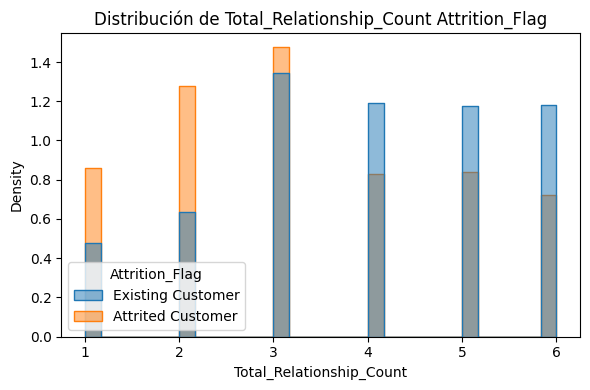

In [ ]:
graficate_distribution("Total_Relationship_Count", 'Attrition_Flag')

Cuantos más productos tenga un cliente en el banco (mayor Total_Relationship_Count), menor es su probabilidad de churn. En cambio, quienes mantienen solo 1–2 productos, muestran una mayor tendencia a abandonar. Esto sugiere que el nivel de vinculación con el banco (número de productos contratados) es un factor clave para la retención.
Podríamos decir que aumentar la vinculación o interdependencia entre los productos puede ser una estrategia efectiva para reducir bajas.

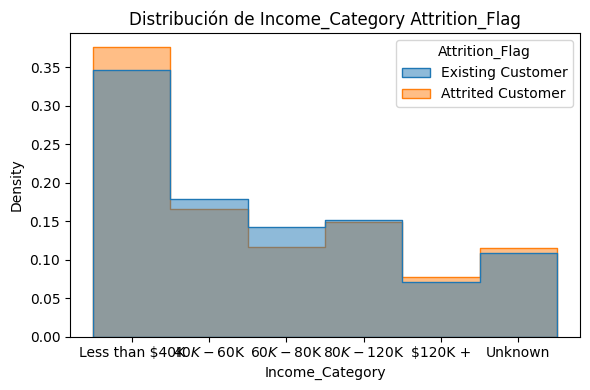

In [ ]:
graficate_distribution("Income_Category", 'Attrition_Flag')

Según la distribución de ingresos para clientes que se van del banco, se puede observar que tanto clientes de ingresos bajos como muy altos tienen una probabilidad relativamente mayor a los clientes existentes para irse del banco (churn).
Con respecto a ingresos medios (entre 40k y 120k) es más probable que el cliente se quede y no se vaya del banco.

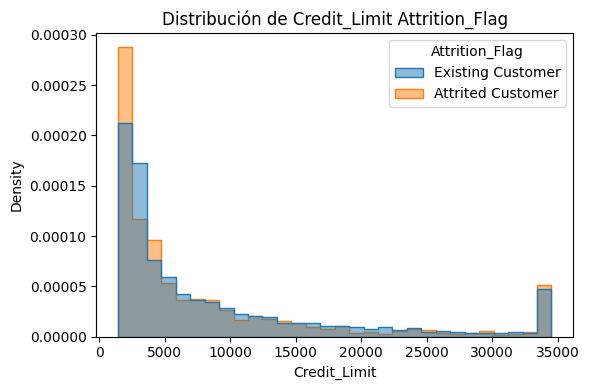

In [ ]:
graficate_distribution("Credit_Limit", 'Attrition_Flag')

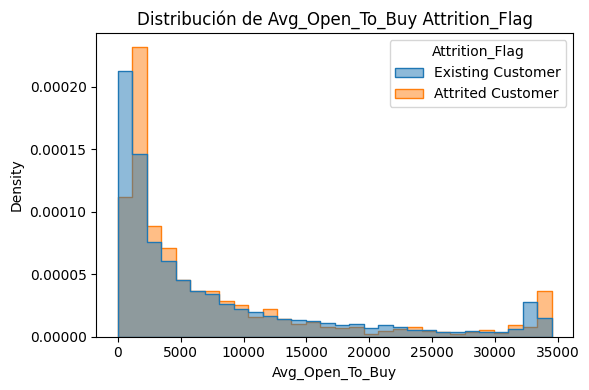

In [ ]:
graficate_distribution("Avg_Open_To_Buy", 'Attrition_Flag')

Al observar conjuntamente las distribuciones de Income_Category, Credit_Limit y Avg_Open_To_Buy con respecto a la variable objetivo Attrition_Flag, se identifican los siguientes patrones:

Los clientes de menores ingresos (Less than 40K) y de mayores ingresos (+120k) son los que muestran mayor proporción de abandono. Sin embargo, los de ingresos medios-altos ($40k a 120K) tienden a permanecer activos.

De forma consistente, los clientes con menores límites de crédito son también los que más abandonan, mientras que los clientes con límites de crédito más altos presentan mayor retención. A excepción del mayor límite de crédito donde están los clientes que más abandonan.

Esta misma tendencia se replica en la variable Avg_Open_To_Buy: los clientes con bajo saldo disponible en su tarjeta muestran mayor churn, mientras que aquellos con mayor disponibilidad (más margen sin usar del límite) se mantienen activos.

En conjunto, esto sugiere que existe una relación directa entre el poder adquisitivo o perfil crediticio del cliente y su nivel de compromiso con el banco.

Los clientes con menores ingresos y menor poder de compra (medido por crédito disponible) pueden sentirse menos satisfechos con el producto financiero, o incluso estar restringidos en su uso, lo que se traduce en mayor probabilidad de abandono.

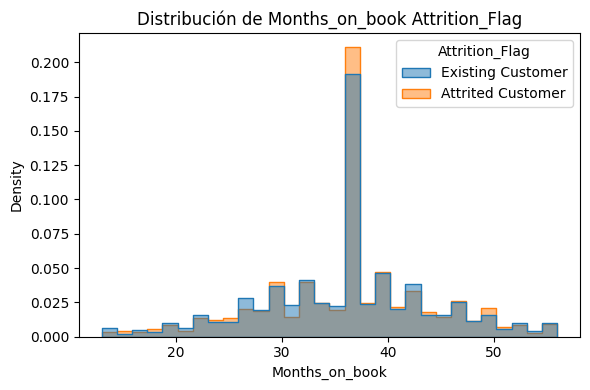

In [ ]:
graficate_distribution("Months_on_book", 'Attrition_Flag')

Acá no notamos una tendenia entre el abandono y la antigüedad del cliente en el banco.

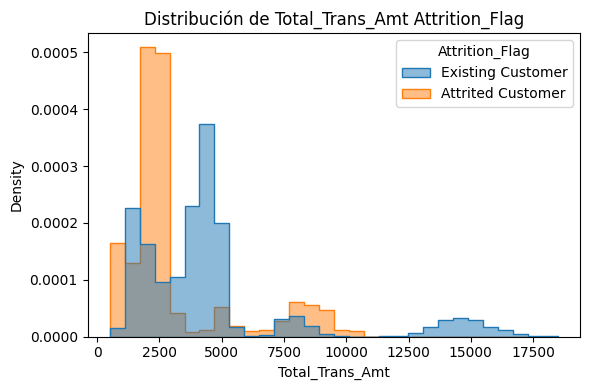

In [ ]:
graficate_distribution("Total_Trans_Amt", 'Attrition_Flag')

Se puede ver cómo hay una tendencia al abandono en clientes que en total transfieren montos más pequeños. Lo que se podría entender con la tendencia de gráficos anteriores (como por ejemplo nivel de ingresos o límite de crédito).

##Análisis de probabilidades condicionales e independencia entre dos variables

¿Existe algún tipo de relación entre la inactividad del cliente y el nivel de endeudamiento?

In [ ]:
inactive = df["Months_Inactive_12_mon"].isin([4,5,6])
high_debt = df['Total_Revolving_Bal'] > df['Total_Revolving_Bal'].mean()

intersection_count = len(df[inactive & high_debt])
most_inactive_clients_count=len(df[ inactive])

prob_cond_above_avg_dada_exp= intersection_count / most_inactive_clients_count

print('%5.4f' % prob_cond_above_avg_dada_exp)

0.5075


De los clientes que llevan entre 4 y 6 meses sin usar la tarjeta, el 50,75 % tiene un saldo refinanciado por encima de la media. Como en toda la población alrededor del 50 % está por encima de la media, esto indica que la inactividad (4–6 meses) no cambia la probabilidad de tener mucha deuda: es decir, no hay relación aparente entre estar inactivo y estar muy endeudado.

In [ ]:
from scipy.stats import chi2_contingency, ttest_ind

high_income = df['Income_Category'] == '$120K +'
high_limit = df['Credit_Limit'] > df['Credit_Limit'].mean()
product_type = df['Card_Category'] == 'Platinum'


ct_income = pd.crosstab(df['Income_Category'], inactive)
chi2_i, p_i, _, _ = chi2_contingency(ct_income)
print(f"Chi2 test Income vs Inactive: χ2={chi2_i:.2f}, p={p_i:.4f}")

ct_card = pd.crosstab(df['Card_Category'], inactive)
chi2_c, p_c, _, _ = chi2_contingency(ct_card)
print(f"Chi2 test Card vs Inactive:   χ2={chi2_c:.2f}, p={p_c:.4f}\n")

limit_inactive = df.loc[inactive, 'Credit_Limit']
limit_active   = df.loc[~inactive, 'Credit_Limit']
t_stat, p_val  = ttest_ind(limit_inactive, limit_active, equal_var=False)
print(f"T-test Credit_Limit (Inactive vs Active): t={t_stat:.2f}, p={p_val:.4f}")

Chi2 test Income vs Inactive: χ2=9.55, p=0.0890
Chi2 test Card vs Inactive:   χ2=5.26, p=0.1538

T-test Credit_Limit (Inactive vs Active): t=-2.81, p=0.0051


**Ingreso vs. Inactividad**

Test χ²: χ² = 9.55, p = 0.0890

p > 0.05 → No hay evidencia estadística de dependencia entre el nivel de ingreso y la inactividad del cliente.

**Tipo de tarjeta vs. Inactividad**

Test χ²: χ² = 5.26, p = 0.1538

p > 0.05 → No se encuentra relación significativa entre la categoría de tarjeta (Platinum u otra) y la inactividad.

**Límite de crédito vs. Inactividad**

Test t (inactivos vs. activos): t = –2.81, p = 0.0051

p < 0.01 → Existe una diferencia significativa en la media de Credit_Limit:
los clientes inactivos tienen en promedio un límite de crédito más bajo que los clientes activos.

**En resumen:**

No hay relación apreciable entre inactividad e ingreso ni entre inactividad y tipo de producto (tarjeta).

Sí existe una relación significativa con el límite de crédito: menores líneas de crédito se asocian a mayor probabilidad de inactividad.

Para profundizar el analisis, se dividió a los clientes en dos grupos:

Alta actividad: clientes con 1 mes o menos de inactividad en el último año.

Baja actividad: clientes con 3 o más meses de inactividad.

A continuación, se presentan los boxplots para distintas variables relevantes del negocio:


,Alta_actividad_media,Baja_actividad_media,Alta_actividad_mediana,Baja_actividad_mediana
Customer_Age,46.064987,46.644120,46.0000,47.000
Total_Relationship_Count,3.835986,3.800349,4.0000,4.000
Credit_Limit,8607.613439,8433.883592,4629.0000,4396.000
Avg_Utilization_Ratio,0.285819,0.272229,0.2025,0.169
Total_Trans_Amt,4653.374005,4283.207288,4044.0000,3814.000
Total_Trans_Ct,67.105217,63.662885,69.0000,66.000
Contacts_Count_12_mon,2.374005,2.486581,2.0000,3.000
Months_on_book,35.582228,36.391228,36.0000,36.000


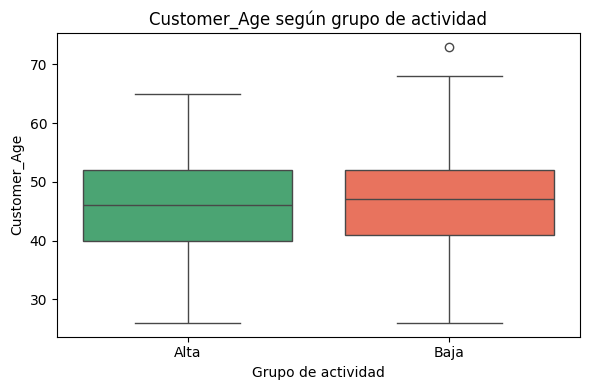

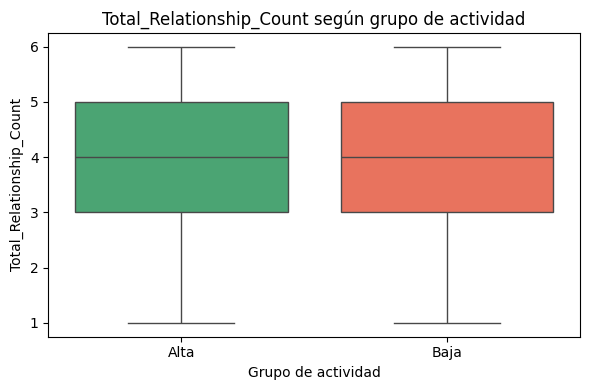

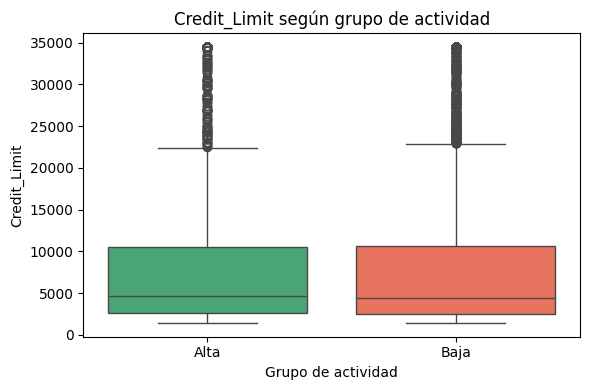

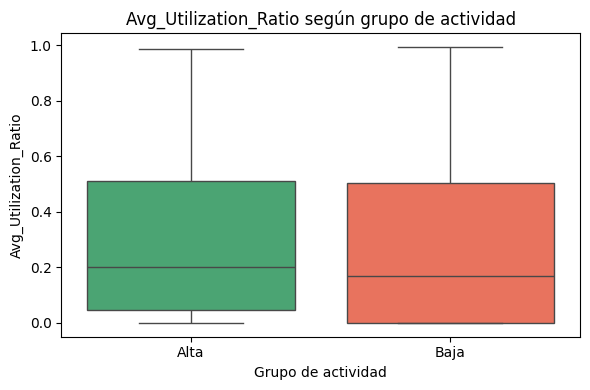

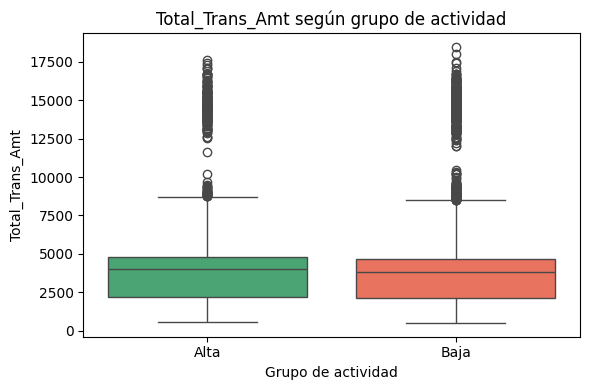

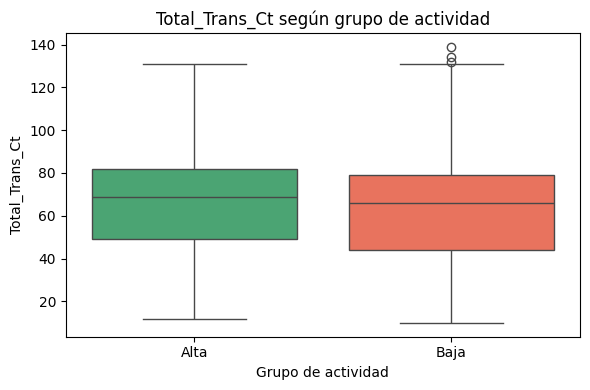

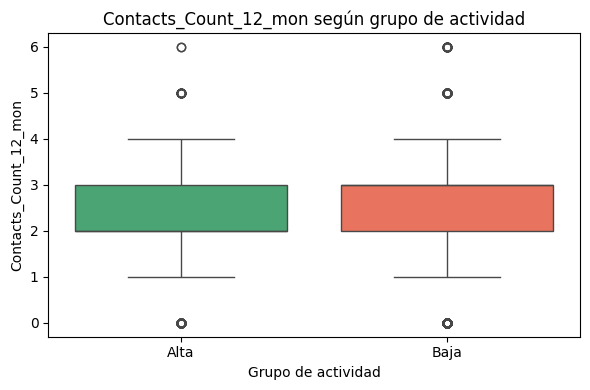

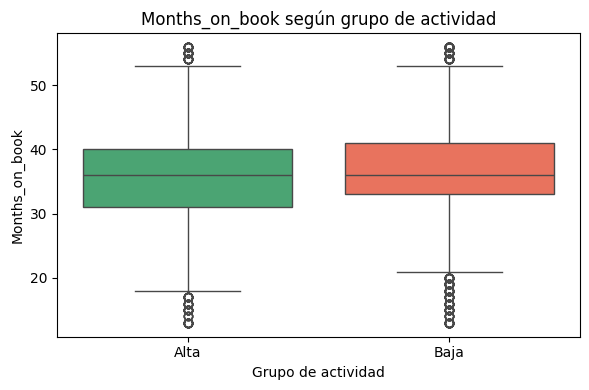

In [ ]:

umbral_alta_actividad = 1  # ≤1 mes inactivo → alta actividad
umbral_baja_actividad = 3  # ≥3 meses inactivo → baja actividad

alta_actividad = df[df['Months_Inactive_12_mon'] <= umbral_alta_actividad]
baja_actividad = df[df['Months_Inactive_12_mon'] >= umbral_baja_actividad]


variables = [
    'Customer_Age',
    'Total_Relationship_Count',
    'Credit_Limit',
    'Avg_Utilization_Ratio',
    'Total_Trans_Amt',
    'Total_Trans_Ct',
    'Contacts_Count_12_mon',
    'Months_on_book'
]


comparativo_actividad = pd.DataFrame({
    'Alta_actividad_media': alta_actividad[variables].mean(),
    'Baja_actividad_media': baja_actividad[variables].mean(),
    'Alta_actividad_mediana': alta_actividad[variables].median(),
    'Baja_actividad_mediana': baja_actividad[variables].median()
})
display(comparativo_actividad)


import matplotlib.pyplot as plt
import seaborn as sns


df['Grupo_actividad'] = pd.cut(
    df['Months_Inactive_12_mon'],
    bins=[-1, umbral_alta_actividad, umbral_baja_actividad-1, 6],
    labels=['Alta', 'Media', 'Baja']
)

for var in variables:

    df_plot = df[df['Grupo_actividad'].isin(['Alta','Baja'])].copy()
    df_plot['Grupo_actividad'] = df_plot['Grupo_actividad'].cat.remove_unused_categories()

    plt.figure(figsize=(6, 4))
    sns.boxplot(
        x='Grupo_actividad',
        y=var,
        hue='Grupo_actividad',
        data=df_plot,
        palette={'Alta':'mediumseagreen', 'Baja':'tomato'},
        dodge=False,
        legend=False
    )
    plt.title(f'{var} según grupo de actividad')
    plt.xlabel('Grupo de actividad')
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()


#### Interpretación

**Edad del cliente (Customer_Age):**

Los clientes de baja actividad tienden a ser ligeramente mayores en comparación con los de alta actividad. La mediana de edad para baja actividad es superior, y el rango intercuartílico también está desplazado hacia valores más altos. Esto sugiere que el riesgo de baja actividad aumenta en clientes de mayor edad.

**Cantidad de productos activos (Total_Relationship_Count):**

La cantidad de productos activos (relaciones con el banco) es bastante similar entre ambos grupos, aunque la dispersión parece ligeramente mayor en clientes de alta actividad. Sin embargo, no se observan diferencias marcadas en la mediana.

**Límite de crédito (Credit_Limit):**

Los clientes de alta actividad tienden a tener límites de crédito mayores en promedio, aunque la dispersión y la presencia de outliers es muy alta en ambos grupos. La mediana de alta actividad es superior, indicando que los clientes más activos suelen acceder a mayores montos de crédito.

**Ratio de utilización del crédito (Avg_Utilization_Ratio):**

El uso del crédito es levemente superior en clientes de alta actividad, aunque las distribuciones son bastante similares. No obstante, los clientes de baja actividad tienen una mayor concentración en valores bajos, indicando poco uso de sus líneas de crédito.

**Monto total de transacciones (Total_Trans_Amt):**

La mediana y la dispersión del monto total transaccionado es superior en los clientes de alta actividad. Los clientes con baja actividad mueven menos dinero a través de sus cuentas, lo que puede reflejar menor compromiso o interés por los productos bancarios.

**Cantidad total de transacciones (Total_Trans_Ct):**

De forma consistente con el monto, los clientes de alta actividad realizan más transacciones al año. La mediana y el rango son superiores respecto a los clientes de baja actividad, confirmando un patrón de mayor uso del banco.

**Contactos con el banco (Contacts_Count_12_mon):**

No se observa una diferencia sustancial en la cantidad de contactos con el banco entre ambos grupos. La mediana es igual o muy similar y la dispersión es baja, lo que sugiere que la frecuencia de contacto puede no ser un buen predictor directo de actividad.

**Antigüedad en el banco (Months_on_book):**

Sorprendentemente, los clientes de baja actividad tienden a tener mayor antigüedad en el banco (mediana más alta). Esto puede indicar que algunos clientes “antiguos” han reducido su actividad y están en riesgo de abandonar la institución.

####  Conclusion general:

Los clientes con baja actividad tienden a ser mayores, tienen menores límites de crédito, mueven menos dinero y realizan menos transacciones en comparación con los de alta actividad. Sin embargo, poseen similar cantidad de productos activos y contactos con el banco, y suelen tener más antigüedad. Estos perfiles sugieren que la baja actividad puede estar asociada a desinterés progresivo, envejecimiento de la cartera y menor engagement, lo que convierte a estos clientes en foco prioritario para estrategias de retención y reactivación por parte del banco.

A continuación se resume las caracteristicas de estos dos grupos de usuarios


| Variable                     | Alta actividad (media) | Baja actividad (media) |
| ---------------------------- | ---------------------- | ---------------------- |
| Edad promedio                | 46.1                   | 48.6                   |
| Productos activos            | 3.84                   | 3.88                   |
| Límite de crédito            | 8,608                  | 7,767                  |
| Ratio utilización crédito    | 0.29                   | 0.28                   |
| Monto total transacciones    | 4,653                  | 4,085                  |
| Cantidad total transacciones | 67.1                   | 63.4                   |
| Contactos con el banco       | 2.37                   | 2.48                   |
| Antigüedad en el banco       | 35.6                   | 38.7                   |



El análisis comparativo muestra que los clientes de baja actividad (≥3 meses inactivos) tienden a:

- Ser, en promedio, más mayores que los clientes activos.

- Tener límites de crédito más bajos, realizar menos transacciones y mover menores montos.

- Hacer menor uso de su crédito disponible.

- Poseer una cantidad similar de productos activos, aunque el compromiso es menor.

- Presentar ligeramente mayor antigüedad en el banco, lo que puede reflejar clientes antiguos que han perdido interés.

- Tener una media levemente mayor de contactos con el banco, posiblemente por gestiones o reclamos.

Estos resultados, que también se aprecian claramente en los boxplots adjuntos, permiten caracterizar al cliente inactivo típico: mayor, menos comprometido, con menor movimiento financiero y menor uso de productos.
Este grupo debería ser el foco de estrategias de reactivación y retención, ya que muestran señales tempranas de desenganche que pueden anticipar el abandono.